**14/08/2026** -- Supplementary figure S3: Posterior predictive checks of the Bayesian hierarchical model

In [1]:
Sys.setenv(PROJ_DATA = "/home/users/cho00/miniconda3/envs/ppca/share/proj")

In [19]:
library(dplyr)
library(brms)
library(rstan)
library(cmdstanr)
library(ggplot2)
library(bayesplot)
library(cowplot)
library(patchwork)


Attaching package: ‘patchwork’


The following object is masked from ‘package:cowplot’:

    align_plots




In [6]:
root <- rprojroot::find_root(rprojroot::has_file(".gitignore"))
source(file.path(root, "src/deprivation_pm_bhm/model_setup.R"))

In [4]:
# Load config
cfg             <- yaml::read_yaml(file.path(root, "configs/bhm_fit_ppca_hu_15kiter_24threads_cfg.yaml"))
data_filepath   <- cfg$project$data_filepath
model_save_dir  <- cfg$project$model_save_dir

In [7]:
# Construct model file path
model_file <- build_modelfile(
    out_path    = model_save_dir,
    model_name  = cfg$model$name,
    outcome     = cfg$model$outcome,
    scale_y     = cfg$data$scale_y,
    pca_method  = cfg$pca$method,
    n_pcs       = cfg$pca$n_pcs,    
    mcmc_cfg    = cfg$mcmc,
    priors_cfg  = cfg$priors,
    max_year    = cfg$data$max_year
)

In [8]:
# Load model
model <- readRDS(model_file)

In [10]:
options(repr.plot.height = 6, repr.plot.width = 12)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


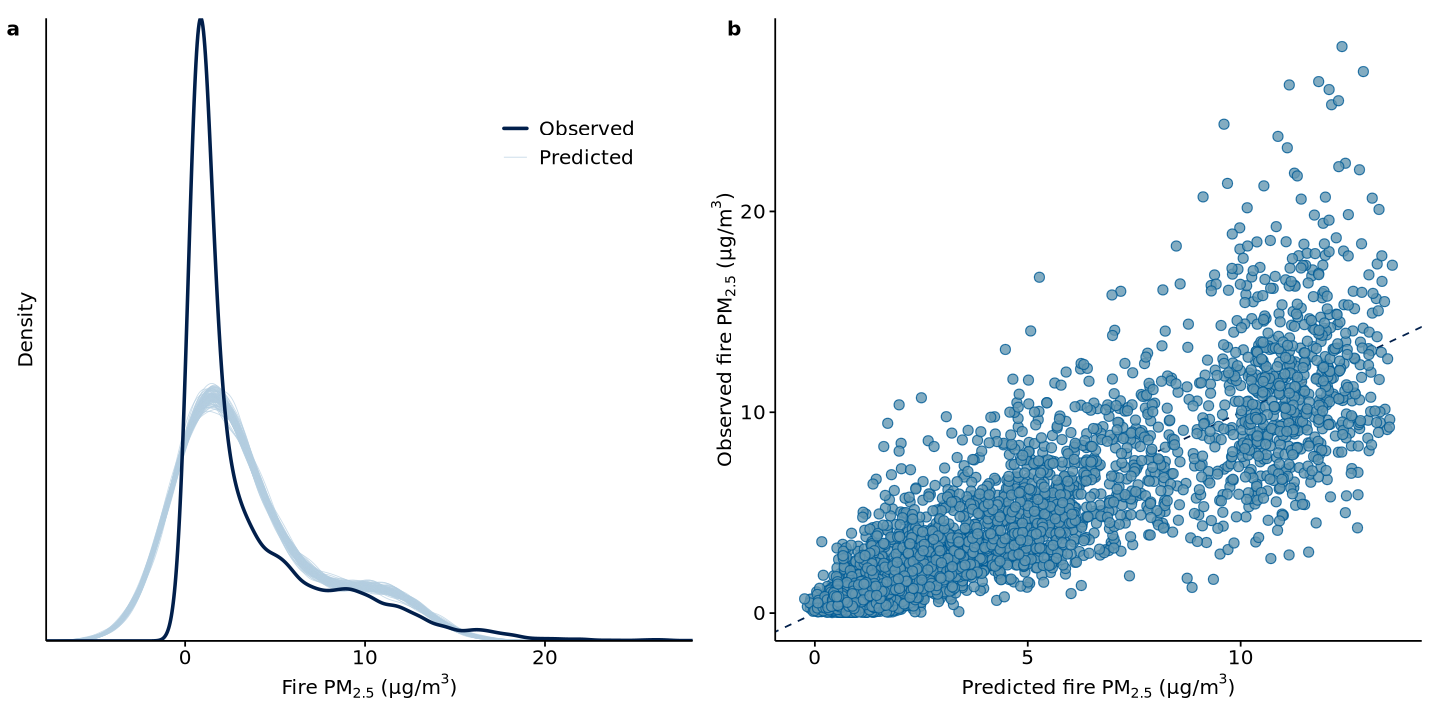

In [25]:
# Do pp_checks for subset of data
set.seed(42)
sampled_data <- model$data %>% sample_n(5000)

# Overlay of observed & predictive distributions of y
pp_dens_overlay <- brms::pp_check(
    model,
    type = "dens_overlay",
    newdata = sampled_data,
    ndraws = 100
) + theme(plot.margin = margin(l = 20))

# Scatter of obs vs. pred
pp_scatter_avg <- brms::pp_check(
    model,
    type = "scatter_avg",
    newdata = sampled_data,
    ndraws = 100
)

# Formatting
pp_dens_overlay <- pp_dens_overlay + 
    scale_color_manual(
        values = c(bayesplot::color_scheme_get("blue")$dark_highlight,
                   bayesplot::color_scheme_get("blue")$light_highlight),
        labels = c("Observed", "Predicted")
    ) +
    labs(
        y = "Density",
        x = expression(paste("Fire ", PM[2.5], 
                             " (", mu, "g/m"^3, ")")),
        colour = NULL
    ) +
    theme_minimal() +
    theme(
        axis.line   = element_line(colour = "black"),
        axis.title  = element_text(colour = "black", size = 12),
        axis.text.x = element_text(colour = "black", size = 12),
        axis.text.y = element_blank(),
        panel.grid.major    = element_blank(),
        panel.grid.minor    = element_blank(),
        axis.ticks.x    = element_line(colour = "black"),
        axis.ticks.length.x = unit(1.2, "mm"),
        legend.text = element_text(colour = "black", size = 12),
        legend.position = "inside",
        legend.position.inside = c(0.8, 0.8)
    )

pp_scatter_avg <- pp_scatter_avg +
    labs(
        y = expression(paste("Observed fire ", PM[2.5], 
                             " (", mu, "g/m"^3, ")")),
        x = expression(paste("Predicted fire ", PM[2.5], 
                             " (", mu, "g/m"^3, ")")),
    ) +
    theme_minimal() +
    theme(
        axis.line   = element_line(colour = "black"),
        axis.title  = element_text(colour = "black", size = 12),
        axis.text   = element_text(colour = "black", size = 12),
        panel.grid.major    = element_blank(),
        panel.grid.minor    = element_blank(),
        axis.ticks  = element_line(colour = "black"),
        axis.ticks.length.y = unit(1.2, "mm"),
        axis.ticks.length.x = unit(1.2, "mm"),
    )

options(repr.plot.width = 12, repr.plot.height = 6)
ggdraw(pp_dens_overlay + pp_scatter_avg) +
    draw_plot_label(
        label = c("a", "b"),
        x = c(0.0, 0.5),   # Adjust x positions
        y = c(0.98, 0.98),   # Adjust y positions
        size = 12, fontface = "bold"
    )

In [26]:
ggsave(
    filename = file.path(root, "paper_results/figures/supplementary_fig_S3.png"),
    width = 12, height = 6, dpi = 450,
    device = grDevices::png,
    bg = "white"
)

In [27]:
set.seed(42)
brms::bayes_R2(
    model,
    newdata = sampled_data,
    ndraws = 100
)

,Estimate,Est.Error,Q2.5,Q97.5
R2,0.7737208,0.0002151509,0.7732958,0.7741392
